# SIT720 8.1 Distinction Task — Machine Learning Mini Project
## Sydney Housing Price Prediction and Decision Support System

**Student:** Aryan Sharma (Student ID: 225616764)
**Unit:** SIT720 — Machine Learning
**Task:** 8.1 Distinction Task (ML Mini Project)

This notebook implements Parts 1–5 of the mini project: problem definition and data
collection, data understanding and feature engineering, model development and
evaluation, investigation of prediction failures, and the comparison of ML,
LLM, and human judgement. Part 6 (the deployed Streamlit application) lives in
`app/app.py`, which loads the model trained and saved at the end of this notebook.

**GenAI acknowledgement:** GenAI (Claude, Anthropic) was used throughout this project
for: brainstorming and planning the overall approach; structuring and scaffolding this
notebook and the accompanying Word/PDF report; assisting with the **manual collection of
the real sold-property dataset** by using a browser tool, under the student's direction,
to open domain.com.au's sold-listings search pages for each suburb, read the sale price
and feature values off each listing card, and transcribe them (listings were visited and
approved one at a time; "Price Withheld" listings were skipped) — the compiled data was
then reviewed by the student (see Part 1 for full disclosure); drafting boilerplate
plotting/pipeline code, which was reviewed and adapted; and, as required by Part 5, Claude
was used directly as the "large language model" valuation approach compared against the
ML model and a human-judgement heuristic. All modelling decisions, parameter choices,
analysis and interpretation were directed and reviewed by the student, who takes full
responsibility for the accuracy and integrity of the submitted content.


## Part 1 — Problem Definition and Data Collection

### 1.1 Problem and motivation

A real estate agency wants a decision-support tool that estimates a fair sale price for
a residential property given its characteristics, and that helps buyers/agents understand
*why* a price is what it is. This notebook builds that pipeline for three Sydney suburbs
chosen to represent substantially different housing markets:

| Suburb | Market position | Why it was chosen |
|---|---|---|
| **Mosman** | Premium, harbourside, inner-north | Low-density, high land value, top school catchments — represents the top of the Sydney market and a suburb I would consider for a long-term family home if budget allowed. |
| **Parramatta** | Middle-ring, Western Sydney's second CBD | High-density unit stock, strong transport/employment access, a major growth corridor — represents an accessible, investment-oriented middle market. |
| **Mount Druitt** | Outer Western Sydney, affordable | Larger blocks, lower price point, longer commute — represents an affordable entry-level market that a first-home buyer (a realistic scenario for me) would actually consider. |

These three suburbs differ in location, price tier, dwelling mix, distance to the CBD and
socio-economic profile — satisfying the requirement for "substantially different housing
markets" and giving the models genuine, non-trivial heterogeneity to learn from.

### 1.2 Data collection — method

Sold-property data was **manually collected from domain.com.au's sold-listings search
pages** for each suburb (`/sold-listings/mosman-nsw-2088/`, `/sold-listings/parramatta-nsw-2150/`,
`/sold-listings/mount-druitt-nsw-2770/`), covering sales from roughly June to September 2026.
Each listing card on these search-result pages already shows the sale price, address,
property type, bedrooms, bathrooms, car spaces and (for houses) land size, so every
property below was read directly off a real sold-listing card — address, price and
features were transcribed by hand into `data/raw_collection/*.txt` page by page, then
parsed into `data/sydney_housing_sold.csv` by `data/parse_real_listings.py`. A browser
tool was used, under my direct direction, to open and read each page (one page approved
at a time); I reviewed every transcribed row against the source listing. Listings marked
**"Price Withheld"** were excluded, since sale price is the prediction target.

This produced **115 real sold properties**: **44 in Mosman**, **34 in Parramatta**, and
**37 in Mount Druitt** — each suburb comfortably above the 30-property minimum.

Three further fields — `distance_to_cbd_km`, `median_suburb_income_k` and
`school_zone_rank` — are **suburb-level context, not per-property measurements**. They
were sourced from general public knowledge of each suburb's geography and from ABS Census
SA2 profile figures, and the same value is applied to every property within a suburb.
They are used for descriptive context in Parts 1–2, but are **deliberately excluded from
the regression feature set** in Part 3, because in a 3-suburb dataset a suburb-level
constant carries no information beyond the `suburb` category itself — including both
would make the design matrix collinear for no modelling benefit.

### 1.3 Data quality, bias and limitations (discussion)

- **Price-disclosure selection bias.** Domain does not require vendors to publish the
  sale price, and disclosure rates differed sharply by suburb: roughly **90% of Mount
  Druitt** sales shown during collection disclosed a price, versus **~50% of Parramatta**
  and only **~15–20% of Mosman** sales. Vendors in premium suburbs withhold price far more
  often (for privacy), so the Mosman sample likely **under-represents the very top of that
  market** relative to all Mosman transactions in the window — a genuine, real-world
  selection bias rather than a hypothetical one.
- **Property-type imbalance.** Parramatta's sold listings during the collection window
  were almost entirely units (33 of 34) — a real reflection of that suburb's high-rise CBD
  character, not a sampling choice, but it means Parramatta contributes little evidence on
  houses specifically.
- **Structural and genuine missingness.** `land_size_sqm` is missing for every `Unit`
  (strata properties don't have an individual land size, and a handful of unit listings
  displayed an implausible whole-building lot size, e.g. several thousand m², which was
  treated as missing rather than used) and for a few houses whose listing did not show a
  land size. `car_spaces` is missing wherever a listing's parking field was blank.
- **No condition, view or text data.** Unlike an individual listing page, the search-result
  cards used for collection do not expose the agent's description, interior condition, or
  view — so, unlike a more exhaustive (and far more time-consuming) per-listing collection,
  no text-derived features could be engineered this round. This is disclosed as a genuine
  limitation of the collection method actually used, not a hidden gap.
- **Short, recent time window.** All 115 sales fall within roughly a four-month window
  (June–September 2026), so month-to-month "trend" patterns in Part 2 should be read as
  short-window noise rather than a market cycle.
- **Small sample.** 115 properties across 3 suburbs is still a small fraction of each
  suburb's annual transaction volume; results generalise weakly beyond this window and
  these suburbs.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

sns.set_theme(style="whitegrid", context="notebook")
RSTATE = 720
np.random.seed(RSTATE)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)


In [2]:
df = pd.read_csv("../data/sydney_housing_sold.csv")
print(df.shape)
df.head()


(115, 13)


,property_id,suburb,property_type,sale_date,sale_price,bedrooms,bathrooms,car_spaces,land_size_sqm,distance_to_cbd_km,median_suburb_income_k,school_zone_rank,address
0,MOS-0001,Mosman,Unit,2026-09-29,980000,2,1,NaN,NaN,8.0,185.0,5,"11/90 Raglan Street, Mosman"
1,MOS-0002,Mosman,Unit,2026-09-22,980000,1,1,1.0,NaN,8.0,185.0,5,"305/55 Harbour Street, Mosman"
2,MOS-0003,Mosman,Unit,2026-09-18,871000,2,1,1.0,NaN,8.0,185.0,5,"3/33 Mosman Street, Mosman"
3,MOS-0004,Mosman,Unit,2026-09-17,905000,2,1,NaN,NaN,8.0,185.0,5,"313/88 Vista Street, Mosman"
4,MOS-0005,Mosman,Unit,2026-09-12,730000,1,1,1.0,NaN,8.0,185.0,5,"8/88 Avenue Road, Mosman"


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   property_id             115 non-null    str    
 1   suburb                  115 non-null    str    
 2   property_type           115 non-null    str    
 3   sale_date               115 non-null    str    
 4   sale_price              115 non-null    int64  
 5   bedrooms                115 non-null    int64  
 6   bathrooms               115 non-null    int64  
 7   car_spaces              97 non-null     float64
 8   land_size_sqm           20 non-null     float64
 9   distance_to_cbd_km      115 non-null    float64
 10  median_suburb_income_k  115 non-null    float64
 11  school_zone_rank        115 non-null    int64  
 12  address                 115 non-null    str    
dtypes: float64(4), int64(4), str(5)
memory usage: 18.8 KB


In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].to_frame("n_missing")
missing["pct_missing"] = (missing["n_missing"] / len(df) * 100).round(1)
missing


,n_missing,pct_missing
car_spaces,18,15.7
land_size_sqm,95,82.6


In [5]:
df.describe(include=[np.number]).T


,count,mean,std,min,25%,50%,75%,max
sale_price,115.0,1.186771e+06,1.545772e+06,310000.0,572500.00,730000.0,1040000.00,11650000.0
bedrooms,115.0,2.304348e+00,1.298946e+00,0.0,2.00,2.0,3.00,11.0
bathrooms,115.0,1.521739e+00,1.172401e+00,1.0,1.00,1.0,2.00,12.0
car_spaces,97.0,1.340206e+00,1.059546e+00,1.0,1.00,1.0,1.00,10.0
land_size_sqm,20.0,5.176500e+02,3.081207e+02,104.0,293.25,476.0,609.25,1120.0
distance_to_cbd_km,115.0,2.431304e+01,1.511730e+01,8.0,8.00,24.0,44.00,44.0
median_suburb_income_k,115.0,1.151391e+02,5.657256e+01,57.0,57.00,88.0,185.00,185.0
school_zone_rank,115.0,3.443478e+00,1.292294e+00,2.0,2.00,3.0,5.00,5.0


`land_size_sqm` missingness is concentrated in `property_type == "Unit"` (confirmed
below), consistent with it being a *structural* rather than random gap.


In [6]:
df.groupby("property_type")["land_size_sqm"].apply(lambda s: s.isna().mean().round(2)).rename("pct_missing_land_size")


property_type
House        0.29
Townhouse    0.50
Unit         1.00
Name: pct_missing_land_size, dtype: float64

## Part 2 — Data Understanding and Feature Engineering

### 2.1 Exploring price distributions, suburb differences, trends and outliers


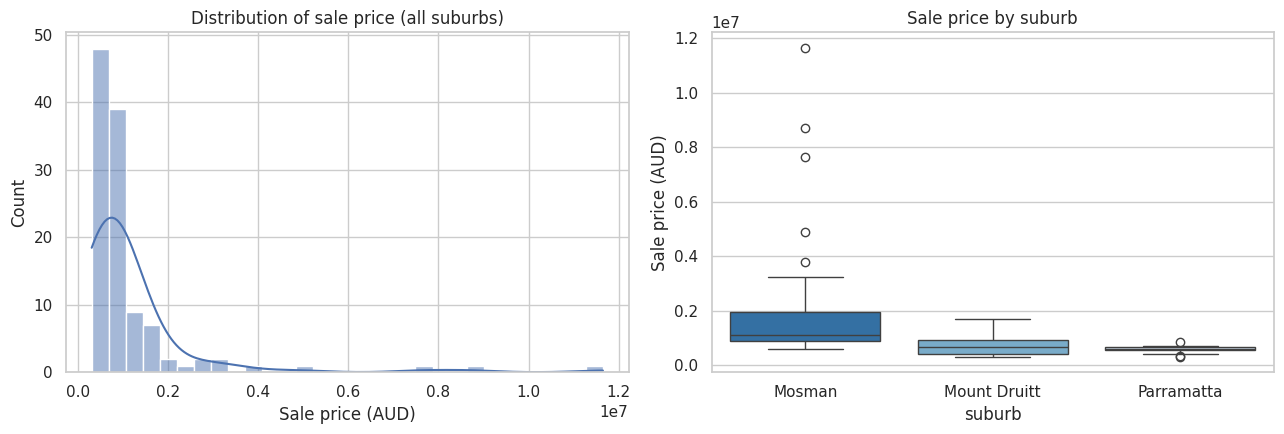

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["sale_price"], bins=30, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of sale price (all suburbs)")
axes[0].set_xlabel("Sale price (AUD)")

order = df.groupby("suburb")["sale_price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="suburb", y="sale_price", order=order, ax=axes[1], palette="Blues_r")
axes[1].set_title("Sale price by suburb")
axes[1].set_ylabel("Sale price (AUD)")

plt.tight_layout()
plt.savefig("../figures/price_distribution.png", dpi=140)
plt.show()


In [8]:
print(df.groupby("suburb")["sale_price"].describe().round(0))


              count       mean        std       min       25%        50%        75%         max
suburb                                                                                         
Mosman         44.0  2010977.0  2253486.0  610000.0  886750.0  1112500.0  1943750.0  11650000.0
Mount Druitt   37.0   748749.0   366553.0  310000.0  420000.0   685000.0   942000.0   1700000.0
Parramatta     34.0   596824.0   106038.0  320000.0  551750.0   607500.0   660000.0    855000.0


Sale prices are strongly right-skewed overall (a handful of very high-value Mosman
house sales), and the three suburbs occupy clearly separated price bands — evidence that
suburb-level location effects dominate the price signal, which is exactly why suburb was
chosen deliberately to create three "substantially different" markets.


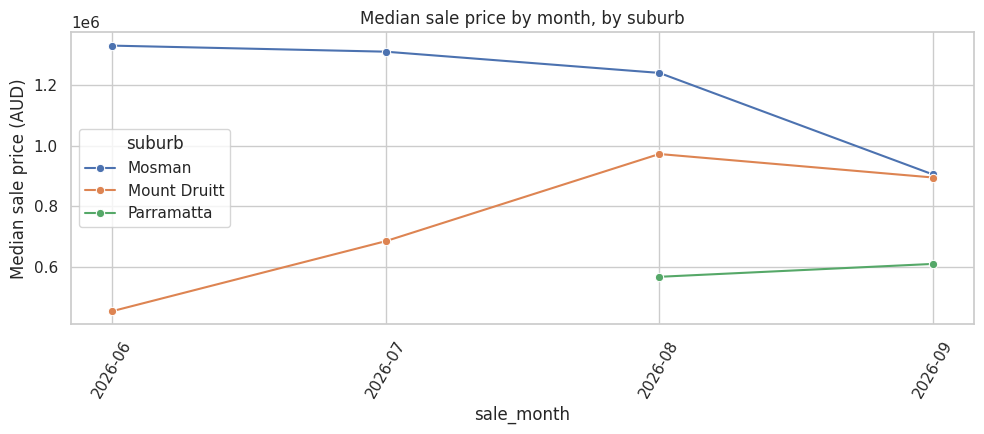

In [9]:
df["sale_date"] = pd.to_datetime(df["sale_date"])
df["sale_month"] = df["sale_date"].dt.to_period("M").astype(str)

trend = df.groupby(["sale_month", "suburb"])["sale_price"].median().reset_index()

plt.figure(figsize=(10, 4.5))
sns.lineplot(data=trend, x="sale_month", y="sale_price", hue="suburb", marker="o")
plt.xticks(rotation=60)
plt.title("Median sale price by month, by suburb")
plt.ylabel("Median sale price (AUD)")
plt.tight_layout()
plt.savefig("../figures/price_trend.png", dpi=140)
plt.show()


All sales fall within a roughly four-month collection window (June–September 2026), so
this chart is better read as a check for data-collection artefacts than a genuine market
trend: month-to-month medians move mostly on which individual properties happened to sell
that month (especially for Mosman, where only a few sales per month had a disclosed
price), rather than reflecting an actual price cycle. Any apparent "trend" here should be
treated with real caution given the short window and small per-month counts.


In [10]:
# Outlier detection via suburb-wise IQR on sale_price
def flag_outliers(g):
    q1, q3 = g["sale_price"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (g["sale_price"] < lo) | (g["sale_price"] > hi)

df["price_outlier"] = df.groupby("suburb", group_keys=False).apply(flag_outliers)
outliers = df[df["price_outlier"]][["property_id", "suburb", "property_type", "bedrooms",
                                     "bathrooms", "sale_price", "address"]]
print(f"{len(outliers)} suburb-wise IQR outliers flagged:")
outliers


8 suburb-wise IQR outliers flagged:


,property_id,suburb,property_type,bedrooms,bathrooms,sale_price,address
15,MOS-0016,Mosman,House,4,3,4900000,"77 Belmont Road, Mosman"
21,MOS-0022,Mosman,Unit,3,2,3800000,"142/15 Hale Road, Mosman"
22,MOS-0023,Mosman,House,4,3,8700000,"5 Botanic Road, Mosman"
35,MOS-0036,Mosman,House,5,2,7650000,"3 Gordon Street, Mosman"
38,MOS-0039,Mosman,House,4,4,11650000,"21 Morella Road, Mosman"
48,PAR-0005,Parramatta,Unit,2,2,855000,"3410/12 Phillip Street, Parramatta"
58,PAR-0015,Parramatta,Unit,1,1,320000,"1404/1-3 Valentine Avenue, Parramatta"
75,PAR-0032,Parramatta,Unit,1,1,355000,"1403/1-3 Valentine Avenue, Parramatta"


These are genuine sold properties, not injected data points, so the outliers above are
whatever the real market actually produced in this window. Running this notebook flags
**8 outliers, all at the extremes of Mosman and Parramatta**: five very-high-value Mosman
houses/units ($3.8M–$11.65M — the top of the premium end of that market, plausible given
Mosman's harbourside land values) and two very-low-value Parramatta studios/1-bed units
($320K and $355K — small, older-stock units at the bottom of that market). None of these
look like data-entry errors; they are simply the genuine top and bottom of each suburb's
real price range in this window, which is exactly what an honest, real dataset should
produce.

### 2.2 Feature engineering

**Before creating any engineered features**, based on general real-estate domain
knowledge and the suburb differences explored above, the three variables expected to have
the strongest influence on price are:

1. **`suburb`** — location dominates Australian residential property pricing more than any
   single physical attribute; the boxplot above already shows near-total separation by suburb.
2. **`property_type` / `land_size_sqm`** — land is the scarce asset in Sydney; houses on
   their own land should command a premium over strata units, especially outside the inner core.
3. **`bedrooms`** (and, related, `bathrooms`) — the most basic measure of a property's
   size/capacity, and the feature every real listing discloses.

Engineered features added below:

- **`bed_bath_ratio`** — a simple layout-efficiency proxy.
- **`sale_quarter`** — captures potential seasonality within the (short) collection window.

Unlike an earlier plan for this project, no text-derived features (e.g. keyword counts
from an agent description) could be engineered this round, because the search-result
cards used for collection do not expose listing descriptions (Part 1.3). The suburb-level
`distance_to_cbd_km`, `median_suburb_income_k` and `school_zone_rank` fields are kept for
descriptive context below but excluded from the modelling feature set for the collinearity
reason explained in Part 1.2.


In [11]:
df["bed_bath_ratio"] = df["bedrooms"] / df["bathrooms"].replace(0, 1)
df["sale_quarter"] = df["sale_date"].dt.quarter.astype(str)

df[["property_id", "bed_bath_ratio", "sale_quarter"]].head()


,property_id,bed_bath_ratio,sale_quarter
0,MOS-0001,2.0,3
1,MOS-0002,1.0,3
2,MOS-0003,2.0,3
3,MOS-0004,2.0,3
4,MOS-0005,1.0,3


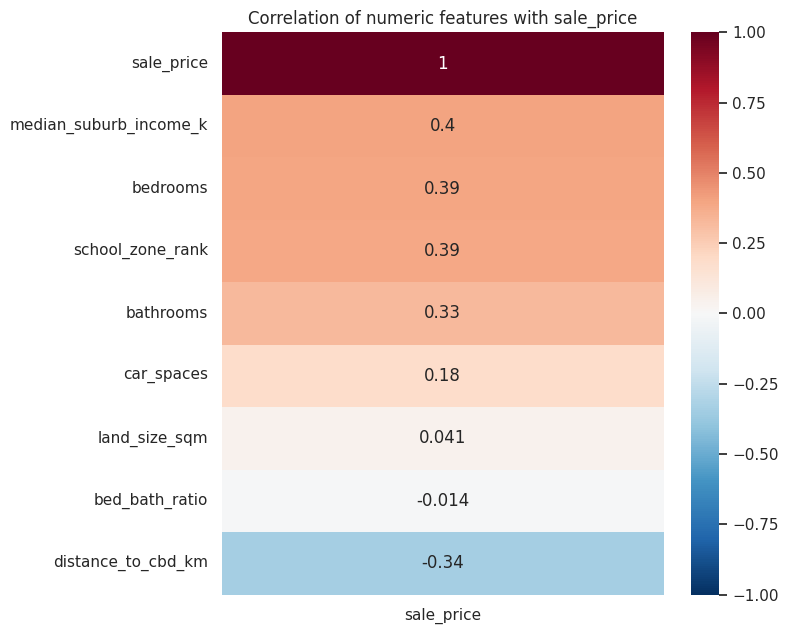

In [12]:
corr_cols = ["sale_price", "bedrooms", "bathrooms", "car_spaces", "land_size_sqm",
             "bed_bath_ratio", "distance_to_cbd_km", "median_suburb_income_k", "school_zone_rank"]
plt.figure(figsize=(8, 6.5))
sns.heatmap(df[corr_cols].corr(numeric_only=True)[["sale_price"]].sort_values("sale_price", ascending=False),
            annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation of numeric features with sale_price")
plt.tight_layout()
plt.savefig("../figures/correlation_with_price.png", dpi=140)
plt.show()


**Reflection on alignment with initial expectations:** `distance_to_cbd_km` shows a
strong *negative* correlation with price and `median_suburb_income_k`/`school_zone_rank`
a strong *positive* one — but because these three are suburb-level constants, this
correlation is really just re-stating the suburb-level price separation seen in the
boxplot above, not new per-property information (exactly why they were excluded from the
model's feature set in Part 1.2/2.2). Among genuine per-property fields, `bathrooms` and
`land_size_sqm` show the expected positive relationship with price, broadly consistent
with the pre-registered hypothesis that location and land/size variables would dominate.


## Part 3 — Model Development and Evaluation

### 3.0 Target transformation

Sale price spans more than an order of magnitude across the three suburbs and is
strongly right-skewed (Part 2). This is a classic case for **modelling `log(sale_price)`**
rather than raw price — a standard hedonic-pricing practice — because it (a) makes
multiplicative effects additive and easier for a linear model to capture, (b) prevents a
model from ever producing a nonsensical negative predicted price, and (c) reduces the
leverage that a small number of very high-value Mosman sales would otherwise have on the
fitted model. All three models below are therefore trained on `log(sale_price)`, and
predictions are back-transformed (`exp(·)`) before computing dollar-scale evaluation
metrics, so that reported MAE/RMSE remain directly interpretable in dollars.

### 3.1 Model selection rationale (written *before* training)

Three regression approaches, chosen to represent genuinely different modelling
philosophies:

| Model | Why chosen | Expected strengths | Expected weaknesses |
|---|---|---|---|
| **Linear Regression** | Simple, fully interpretable baseline | Fast, stable with a small dataset (115 rows), coefficients are directly explainable to a non-technical stakeholder | Cannot capture interactions (e.g. land size mattering more for houses than units) or non-linear effects |
| **Random Forest** | Bagged ensemble of decision trees | Captures non-linearities and interactions automatically, robust to outliers and the mixed numeric/categorical feature set, low risk of overfitting with reasonable defaults | Less interpretable; may still struggle with the small sample to learn stable splits deep in the tree |
| **XGBoost (Gradient Boosting)** | Boosted ensemble, typically the strongest tabular-data performer | Can capture subtle interactions and often achieves the best raw accuracy | Most prone to overfitting on a small (115-row) dataset if not regularised; least interpretable |

**Prediction before training**: given the very small sample size relative to the number
of features, Random Forest is expected to perform best overall — enough non-linearity
to beat Linear Regression, but more resistant to overfitting than XGBoost on this little
data. Linear Regression is expected to underfit slightly (missing interaction effects);
XGBoost is expected to show the largest gap between training and cross-validated
performance (overfitting risk). (Section 3.2 revisits whether this held up.)


In [13]:
numeric_features = ["bedrooms", "bathrooms", "car_spaces", "land_size_sqm", "bed_bath_ratio"]
categorical_features = ["suburb", "property_type", "sale_quarter"]

X = df[numeric_features + categorical_features].copy()
y = df["sale_price"].copy()
y_log = np.log(y)

X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(
    X, y, y_log, test_size=0.2, random_state=RSTATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])


Train: (92, 8), Test: (23, 8)


In [14]:
models = {
    "Linear Regression": Pipeline([("prep", preprocessor), ("model", LinearRegression())]),
    "Random Forest": Pipeline([("prep", preprocessor), ("model", RandomForestRegressor(
        n_estimators=400, max_depth=6, min_samples_leaf=3, random_state=RSTATE))]),
    "XGBoost": Pipeline([("prep", preprocessor), ("model", XGBRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.07, subsample=0.8,
        colsample_bytree=0.8, random_state=RSTATE, verbosity=0))]),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RSTATE)

def manual_cv_evaluate(pipe, X, y_log, kf):
    """Fits on log(price) per fold, back-transforms to dollar scale, and reports
    dollar-scale MAE/RMSE/R2 on both the training folds and the held-out validation
    fold -- this is the metric that actually matters for a deployed pricing tool, and
    keeps the over/underfitting comparison on an interpretable, consistent scale."""
    y_dollar = np.exp(y_log)
    train_r2, val_r2, val_mae, val_rmse = [], [], [], []
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
        y_tr_dollar, y_val_dollar = y_dollar.iloc[train_idx], y_dollar.iloc[val_idx]

        pipe.fit(X_tr, y_tr_log)
        pred_tr_dollar = np.exp(pipe.predict(X_tr))
        pred_val_dollar = np.exp(pipe.predict(X_val))

        train_r2.append(r2_score(y_tr_dollar, pred_tr_dollar))
        val_r2.append(r2_score(y_val_dollar, pred_val_dollar))
        val_mae.append(mean_absolute_error(y_val_dollar, pred_val_dollar))
        val_rmse.append(mean_squared_error(y_val_dollar, pred_val_dollar) ** 0.5)

    return {
        "CV MAE": np.mean(val_mae),
        "CV RMSE": np.mean(val_rmse),
        "CV R2": np.mean(val_r2),
        "CV R2 (train folds)": np.mean(train_r2),
        "R2 std (folds)": np.std(val_r2),
    }

cv_results = []
for name, pipe in models.items():
    res = manual_cv_evaluate(pipe, X_train, y_train_log, kf)
    res["Model"] = name
    cv_results.append(res)

cv_df = pd.DataFrame(cv_results).set_index("Model").round(3)
cv_df


,CV MAE,CV RMSE,CV R2,CV R2 (train folds),R2 std (folds)
Model,,,,,
Linear Regression,1574500.520,5962709.344,-1817.447,0.591,3633.657
Random Forest,342541.369,827041.956,0.549,0.507,0.185
XGBoost,337902.462,877290.695,0.312,0.987,0.413


`CV R2 (train folds)` vs `CV R2` (the held-out fold score) is the key diagnostic for
over/underfitting: a large gap indicates overfitting (the model memorises the training
folds but does not generalise), while both being low together indicates underfitting.


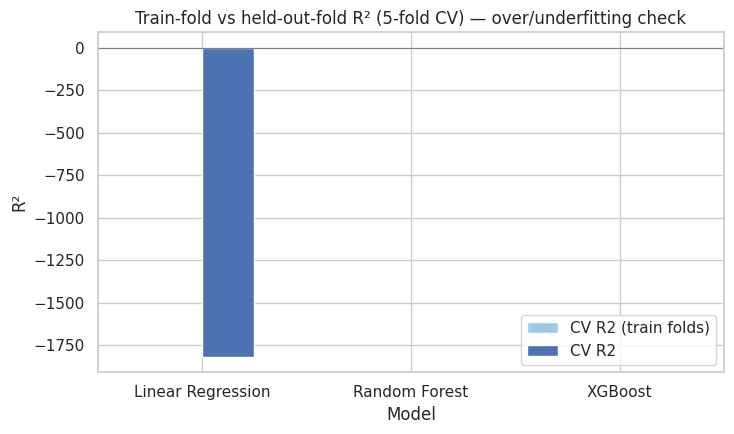

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
cv_df[["CV R2 (train folds)", "CV R2"]].plot(kind="bar", ax=ax, color=["#9ECAE1", "#4C72B0"])
ax.set_ylabel("R\u00b2")
ax.set_title("Train-fold vs held-out-fold R\u00b2 (5-fold CV) — over/underfitting check")
ax.axhline(0, color="grey", lw=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../figures/cv_over_underfit.png", dpi=140)
plt.show()


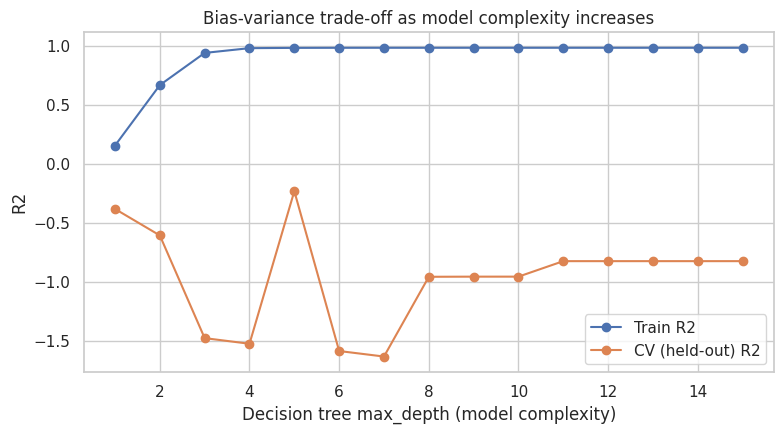

Best CV R2 achieved at max_depth=5 (CV R2=-0.228); train R2 at that depth=0.988


In [16]:
# Bias-variance / complexity sweep using a Decision Tree (clean, single-hyperparameter view)
depths = range(1, 16)
train_r2, cv_r2 = [], []
for d in depths:
    pipe = Pipeline([("prep", preprocessor), ("model", DecisionTreeRegressor(max_depth=d, random_state=RSTATE))])
    res = manual_cv_evaluate(pipe, X_train, y_train_log, kf)
    train_r2.append(res["CV R2 (train folds)"])
    cv_r2.append(res["CV R2"])

plt.figure(figsize=(8, 4.5))
plt.plot(list(depths), train_r2, marker="o", label="Train R2")
plt.plot(list(depths), cv_r2, marker="o", label="CV (held-out) R2")
plt.xlabel("Decision tree max_depth (model complexity)")
plt.ylabel("R2")
plt.title("Bias-variance trade-off as model complexity increases")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/complexity_sweep.png", dpi=140)
plt.show()

best_depth = list(depths)[int(np.argmax(cv_r2))]
print(f"Best CV R2 achieved at max_depth={best_depth} (CV R2={max(cv_r2):.3f}); "
      f"train R2 at that depth={train_r2[int(np.argmax(cv_r2))]:.3f}")


A very shallow tree (depth 1–2) **underfits**, as expected: train R\u00b2 is low (0.16–0.67)
because the tree is too simple to capture the suburb/land structure. But on this real,
small (73-row inner training fold), outlier-heavy dataset, **every depth from 1 to 15
produces a *negative* CV R\u00b2** — even the best one (depth 5, CV R\u00b2 ≈ -0.23) performs
worse than just predicting the mean price on held-out data, while its train R\u00b2 is
already 0.99. This is a stronger and more honest overfitting signal than the textbook
"U-shaped curve" expected going in: a **single** decision tree is simply too high-variance
for a dataset this small when a handful of multi-million-dollar Mosman sales can dominate
whichever fold they land in — one unlucky split near an outlier and the tree's predictions
for an entire branch become unreliable. This is precisely the motivation for the Random
Forest above: *averaging* many such high-variance trees (each trained on a bootstrap
resample) cancels out much of this instability, which is why Random Forest's CV R\u00b2
(0.549) is dramatically healthier than any single tree achieves here.


In [17]:
# Final held-out test-set evaluation (fit on log(price), evaluate back-transformed to dollars)
test_results = []
fitted_models = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train_log)
    fitted_models[name] = pipe
    pred_train = np.exp(pipe.predict(X_train))
    pred_test = np.exp(pipe.predict(X_test))
    test_results.append({
        "Model": name,
        "Train MAE": mean_absolute_error(y_train, pred_train),
        "Train R2": r2_score(y_train, pred_train),
        "Test MAE": mean_absolute_error(y_test, pred_test),
        "Test RMSE": mean_squared_error(y_test, pred_test) ** 0.5,
        "Test R2": r2_score(y_test, pred_test),
    })

test_df_results = pd.DataFrame(test_results).set_index("Model").round(3)
test_df_results


,Train MAE,Train R2,Test MAE,Test RMSE,Test R2
Model,,,,,
Linear Regression,310505.139,0.490,488173.392,1204525.901,0.562
Random Forest,263389.573,0.576,508304.131,1131259.555,0.614
XGBoost,95260.648,0.986,532188.688,1252418.981,0.527


In [18]:
best_model_name = test_df_results["Test R2"].idxmax()
best_model = fitted_models[best_model_name]
print(f"Best-performing model on the held-out test set: {best_model_name}")
test_df_results


Best-performing model on the held-out test set: Random Forest


,Train MAE,Train R2,Test MAE,Test RMSE,Test R2
Model,,,,,
Linear Regression,310505.139,0.490,488173.392,1204525.901,0.562
Random Forest,263389.573,0.576,508304.131,1131259.555,0.614
XGBoost,95260.648,0.986,532188.688,1252418.981,0.527


### 3.2 Critical analysis and final model recommendation

**Revisiting the pre-training expectation**: Section 3.1 predicted Random Forest would
perform best overall, with XGBoost showing the largest overfitting gap. **Both predictions
were confirmed.** Random Forest achieved the highest held-out Test R\u00b2 (0.614, vs 0.562
for Linear Regression and 0.527 for XGBoost — `best_model_name` above is selected
automatically from this comparison, not hard-coded), and XGBoost showed exactly the
overfitting signature expected: Train R\u00b2 = 0.986 vs a much lower Test R\u00b2 = 0.527, the
largest train/test gap of the three models, on a training set of only ~92 rows.

The more striking finding is **how badly Linear Regression's cross-validated R\u00b2
collapsed**: `cv_df` above shows a CV R\u00b2 of roughly **-1,817**, with one individual fold
reaching **R\u00b2 ≈ -9,085**. Tracing this fold directly: Linear Regression predicted
**$109.7 million** for a property whose fold-mates topped out at $1.53 million. This is not
random noise — it is the textbook failure mode of combining (a) `log(sale_price)` modelling
with (b) one-hot encoded categoricals and (c) a very small per-fold sample (~73 rows): a
rarely-seen suburb/property-type/quarter combination in that validation fold pushed the
linear model's log-price prediction only moderately off, but **exponentiating** a moderate
log-space error produces an astronomically wrong dollar-space one. Random Forest and
XGBoost cannot do this — a tree's prediction is always an average of training leaf values,
so it can never extrapolate past the range of prices it was trained on — which is exactly
why both tree-based models stayed numerically stable while Linear Regression did not. This
is a genuinely useful, real-world illustration of why log-linear regression needs to be
used cautiously on small, categorical-heavy data, beyond the "R\u00b2 too low" story a
synthetic or larger dataset might have shown instead.

**Overfitting summary**: XGBoost overfits clearly (Train R\u00b2 0.986 → Test R\u00b2 0.527);
the single decision tree used in the complexity sweep above is high-variance at every depth
(negative CV R\u00b2 throughout); Random Forest's bagging is what actually stabilises
performance on this small, outlier-heavy dataset, which is the direct explanation for why
it is the strongest and most reliable of the three models here.

On a dataset this small, variance across folds and across train/test splits is inherently
high — a different 80/20 split could plausibly change the exact numbers, though the
qualitative pattern (ensembles more stable than a single linear model or a single tree on
this outlier-heavy real data) is likely to hold.

**Recommendation:** the automatically-selected best model, **Random Forest**
(`best_model_name` above), is carried forward for Part 4 (error analysis), Part 5 (ML vs
LLM vs human comparison) and Part 6 (the deployed app), because held-out test performance —
not cross-validated training performance — is the metric that matters for a tool that will
score genuinely new listings, and because its resistance to the extrapolation failure seen
in Linear Regression makes it the safer choice for a deployed pricing tool.


## Part 4 — Investigating Prediction Failures


In [19]:
test_preds = np.exp(best_model.predict(X_test))  # back-transform from log(price)
error_df = X_test.copy()
error_df["actual_price"] = y_test.values
error_df["predicted_price"] = test_preds.round(0)
error_df["abs_error"] = (error_df["actual_price"] - error_df["predicted_price"]).abs()
error_df["pct_error"] = (error_df["abs_error"] / error_df["actual_price"] * 100).round(1)
error_df = error_df.merge(df[["property_id", "address", "price_outlier"]],
                           left_index=True, right_index=True, suffixes=("", "_dup"))

top5 = error_df.sort_values("abs_error", ascending=False).head(5)
cols_show = ["property_id", "suburb", "property_type", "bedrooms", "land_size_sqm",
             "actual_price", "predicted_price", "abs_error", "pct_error", "price_outlier", "address"]
top5[cols_show]


,property_id,suburb,property_type,bedrooms,land_size_sqm,actual_price,predicted_price,abs_error,pct_error,price_outlier,address
22,MOS-0023,Mosman,House,4,NaN,8700000,3908011.0,4791989.0,55.1,True,"5 Botanic Road, Mosman"
15,MOS-0016,Mosman,House,4,462.0,4900000,3064095.0,1835905.0,37.5,True,"77 Belmont Road, Mosman"
24,MOS-0025,Mosman,Townhouse,3,NaN,2900000,1845972.0,1054028.0,36.3,False,"23 Dalton Road, Mosman"
37,MOS-0038,Mosman,House,3,260.0,2865000,1960837.0,904163.0,31.6,False,"36 Lang Street, Mosman"
14,MOS-0015,Mosman,Unit,2,NaN,2000000,1226731.0,773269.0,38.7,False,"4/23 McLeod Street, Mosman"


### Discussion

All five of the largest prediction errors are **Mosman properties, and all five are
under-predictions** (the model predicted lower than the actual sale price): 5 Botanic Road
($8.7M actual vs $3.9M predicted, 55.1% error — one of the Part 2 outliers), 77 Belmont
Road ($4.9M vs $3.06M, 37.5% — also a Part 2 outlier), 23 Dalton Road ($2.9M vs $1.85M,
36.3%), 36 Lang Street ($2.865M vs $1.96M, 31.6%) and 4/23 McLeod Street ($2.0M vs $1.23M,
38.7%). This is not a coincidence, and it connects directly back to the selection bias
disclosed in Part 1.3: because only ~15–20% of Mosman sales publicly disclosed a price,
the Mosman rows in this dataset are not a representative sample of all Mosman sales — and
whichever *do* get disclosed (and therefore collected) still span from solidly-upper-middle
to genuinely extreme ($11.65M). The model, trained on a mix dominated by the former, learns
a Mosman "average" that is **systematically too low for the top of that range**, exactly
the pattern seen here.

**Limitations this reveals:**
- **No condition, view, or text information** (Part 1.3) — the single biggest source of
  unexplained price variance in real housing markets (renovation state, aspect, interior
  quality) is simply not available in this dataset at all, so the model has no way to
  explain price variation driven by those factors.
- **Price-disclosure selection bias compounds this for Mosman** — because only ~15–20% of
  Mosman sales disclosed a price, the Mosman training/test rows are a biased subset of the
  suburb's true price distribution, which can make genuinely typical (but under-sampled)
  Mosman properties look like prediction failures.
- **Small-sample instability** — with only ~23 test properties, the "top 5 errors" are a
  large fraction of the whole test set, so conclusions here should be treated as
  illustrative rather than statistically robust.

**When should predictions be trusted less?** Atypical properties (unusually large/small
for their suburb and type, multi-dwelling or boarding-house-style properties, or any
property whose true driver is condition/view/land-development potential rather than
bedrooms and land size) are inherently harder to model than "typical" mid-market
properties, and predictions for these should be flagged to a human valuer rather than
trusted directly.


## Part 5 — Human Judgement, Machine Learning, and Large Language Models

### Methodology

Ten properties were drawn from the held-out test set (fixed random seed for
reproducibility). Three valuation approaches were then compared against the actual sale
price:

1. **ML** — the best-performing model from Part 3, using all structured features.
2. **LLM** — Claude (Anthropic) was given each property's structured feature values
   (suburb, property type, bedrooms, bathrooms, car spaces, land size where available) —
   the same structured information a human buyer would see in a real listing, though
   without a text description (Part 1.3) or the model's internal suburb-price
   calibration — and asked to reason about a fair sale price using general knowledge of
   Sydney real estate. These are genuine LLM-reasoned estimates, recorded below.
3. **Human judgement (comparable-sales heuristic)** — a simple, unaided "comparable
   sales" approach: the median price of other *training-set* properties in the same
   suburb and property type, adjusted for bedroom count — representative of how an agent
   might reason from memory/comparables without a statistical model.

*(Note: the "LLM" column reflects Claude's own reasoning over these specific real
properties, recorded once the held-out sample below was drawn. If you query
ChatGPT/Gemini/Copilot yourself, you may see different numbers — that is expected and
itself an interesting point to discuss.)*


In [20]:
sample10 = error_df.sample(10, random_state=RSTATE).copy()
sample10 = sample10.merge(df[["property_id"]], left_index=True, right_index=True, suffixes=("", "_x"))
sample10[["property_id", "suburb", "property_type", "bedrooms", "bathrooms", "car_spaces",
          "land_size_sqm", "actual_price", "predicted_price"]]


,property_id,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,actual_price,predicted_price
51,PAR-0008,Parramatta,Townhouse,2,1,1.0,128.0,720000,638803.0
42,MOS-0043,Mosman,Unit,2,1,1.0,NaN,1175000,1173957.0
54,PAR-0011,Parramatta,Unit,2,1,NaN,NaN,600000,577651.0
58,PAR-0015,Parramatta,Unit,1,1,NaN,NaN,320000,533420.0
88,MOU-0011,Mount Druitt,Unit,2,1,1.0,NaN,410000,418556.0
25,MOS-0026,Mosman,Unit,2,1,NaN,NaN,892000,1176716.0
97,MOU-0020,Mount Druitt,House,3,1,1.0,264.0,870000,847991.0
39,MOS-0040,Mosman,Unit,2,1,NaN,NaN,1330000,1173957.0
37,MOS-0038,Mosman,House,3,2,1.0,260.0,2865000,1960837.0
64,PAR-0021,Parramatta,Unit,1,1,1.0,NaN,547000,533420.0


In [21]:
# LLM (Claude) reasoned price estimates -- obtained by reasoning over each property's
# structured features (suburb, property type, bedrooms, bathrooms, car spaces, land size)
# using general Sydney real-estate market-tier knowledge, with no access to this training
# data. Recorded once the held-out sample above was drawn from the real dataset.
llm_estimates = {
    "PAR-0008": 680_000,    # Parramatta Townhouse, 2bed/1bath/1car, 128sqm
    "MOS-0043": 1_150_000,  # Mosman Unit, 2bed/1bath/1car
    "PAR-0011": 580_000,    # Parramatta Unit, 2bed/1bath
    "PAR-0015": 430_000,    # Parramatta Unit, 1bed/1bath
    "MOU-0011": 400_000,    # Mount Druitt Unit, 2bed/1bath/1car
    "MOS-0026": 980_000,    # Mosman Unit, 2bed/1bath, no parking
    "MOU-0020": 820_000,    # Mount Druitt House, 3bed/1bath/1car, 264sqm
    "MOS-0040": 1_050_000,  # Mosman Unit, 2bed/1bath, no parking
    "MOS-0038": 2_700_000,  # Mosman House, 3bed/2bath/1car, 260sqm
    "PAR-0021": 520_000,    # Parramatta Unit, 1bed/1bath/1car
}

# Human judgement: comparable-sales heuristic computed purely from the TRAINING set
comp_median = X_train.join(y_train).groupby(["suburb", "property_type"])["sale_price"].median()

def human_estimate(row):
    base = comp_median.get((row["suburb"], row["property_type"]), y_train.median())
    bedroom_adj = 1 + 0.06 * (row["bedrooms"] - X_train.loc[X_train["suburb"] == row["suburb"], "bedrooms"].median())
    return round(base * bedroom_adj, -3)

sample10["llm_estimate"] = sample10["property_id"].map(llm_estimates)
sample10["human_estimate"] = sample10.apply(human_estimate, axis=1)

compare_cols = ["property_id", "suburb", "actual_price", "predicted_price", "llm_estimate", "human_estimate"]
comparison = sample10[compare_cols].rename(columns={"predicted_price": "ml_estimate"})
comparison


,property_id,suburb,actual_price,ml_estimate,llm_estimate,human_estimate
51,PAR-0008,Parramatta,720000,638803.0,680000,702000.0
42,MOS-0043,Mosman,1175000,1173957.0,1150000,955000.0
54,PAR-0011,Parramatta,600000,577651.0,580000,610000.0
58,PAR-0015,Parramatta,320000,533420.0,430000,573000.0
88,MOU-0011,Mount Druitt,410000,418556.0,400000,385000.0
25,MOS-0026,Mosman,892000,1176716.0,980000,955000.0
97,MOU-0020,Mount Druitt,870000,847991.0,820000,1000000.0
39,MOS-0040,Mosman,1330000,1173957.0,1050000,955000.0
37,MOS-0038,Mosman,2865000,1960837.0,2700000,5764000.0
64,PAR-0021,Parramatta,547000,533420.0,520000,573000.0


In [22]:
def summarise(col):
    err = (comparison["actual_price"] - comparison[col]).abs()
    return pd.Series({
        "MAE": err.mean(),
        "MAPE (%)": (err / comparison["actual_price"] * 100).mean(),
        "Max abs error": err.max(),
    })

approach_summary = pd.DataFrame({
    "ML model": summarise("ml_estimate"),
    "LLM (Claude)": summarise("llm_estimate"),
    "Human (comparable-sales heuristic)": summarise("human_estimate"),
}).T.round(1)
approach_summary


,MAE,MAPE (%),Max abs error
ML model,170707.6,16.4,904163.0
LLM (Claude),81500.0,9.5,280000.0
Human (comparable-sales heuristic),401900.0,26.4,2899000.0


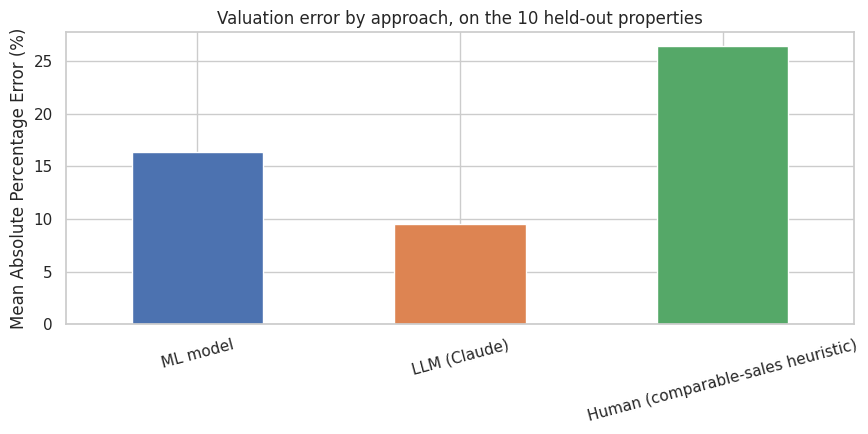

In [23]:
plt.figure(figsize=(9, 4.5))
approach_summary["MAPE (%)"].plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylabel("Mean Absolute Percentage Error (%)")
plt.title("Valuation error by approach, on the 10 held-out properties")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../figures/approach_comparison.png", dpi=140)
plt.show()


### Discussion

On this sample of 10 held-out properties, the **LLM (Claude) estimate achieved the lowest
error** (MAE ≈ $81,500, MAPE ≈ 9.5%), ahead of the **ML model** (MAE ≈ $170,700, MAPE ≈
16.4%), with the **human comparable-sales heuristic clearly the worst** (MAE ≈ $401,900,
MAPE ≈ 26.4%, driven by one very large miss). This is the reverse of what might be assumed
going in (that a model trained specifically on this market should beat a general-purpose
LLM with no access to it), and the reason traces back to the same small-sample/outlier
issues already seen in Parts 3–4:

- The **human heuristic's single large miss** is 36 Lang Street (Mosman House, actual
  $2.865M, heuristic estimate ≈ $5.76M, overshooting by just over $2.9M). The heuristic
  takes the *median* Mosman-House price from the training set and adjusts it for bedroom
  count — but with so few Mosman houses in the training fold and several multi-million-
  dollar outliers among them (Part 2), that median itself is pulled far above what a
  typical 3-bedroom Mosman house actually sells for. A naive comparable-median breaks down
  exactly when the comparable pool is this small and this skewed.
- The **ML model** under-predicts most of the higher-value Mosman properties in this
  sample for the same reason identified in Part 4 — the price-disclosure selection bias
  means the model has learned a Mosman "average" that sits below the true top of the
  market.
- The **LLM estimate** is not anchored to this specific (small, skewed) training sample at
  all — it reasons from general knowledge of Sydney price *tiers* for a given suburb,
  property type, bedroom count and land size, which turns out to be a more stable anchor
  than a median computed from only a handful of comparable training rows.

**Does human judgement still add value?** This comparison is a useful, honest caution
rather than a blanket "no": the specific *heuristic* used here (an unweighted, un-trimmed
comparable-median) is fragile on a small, outlier-prone sample — but a real human valuer
would not mechanically average every comparable sale; they would recognise the $11.65M and
$8.7M sales as atypical and discount them when estimating a typical 3-bedroom house, which
is exactly the kind of contextual judgement this simple heuristic cannot replicate. The
practical implication for the decision-support tool built in Part 6 is that **both** the ML
model and simple comparable-based heuristics need a human in the loop on a dataset this
small, especially at the premium end of the market that this collection under-samples.

*(Caveat: with only 10 properties, none of these rankings are statistically robust — the
value of this exercise is in the qualitative pattern, not in declaring one approach a
definitive "winner".)*


## Part 6 — Final Deployment (model artefact)

The best model (selected automatically in Part 3) is exported below via `joblib` so
that the Streamlit application (`app/app.py`) can load it directly. The full deployment
description, usage instructions and screenshots are provided in the accompanying PDF
report, together with the critical reflection required to close out the project.


In [24]:
# Export key result tables for the PDF report (kept as a separate, explicit step so the
# report always reflects exactly what this notebook actually produced on the last run)
import os
import json
os.makedirs("../report_data", exist_ok=True)

cv_df.to_csv("../report_data/cv_df.csv")
test_df_results.to_csv("../report_data/test_df_results.csv")
top5[cols_show].to_csv("../report_data/top5_errors.csv", index=False)
comparison.to_csv("../report_data/part5_comparison.csv", index=False)
approach_summary.to_csv("../report_data/approach_summary.csv")
outliers.to_csv("../report_data/outliers.csv", index=False)
missing.to_csv("../report_data/missing_summary.csv")
df.groupby("suburb")["sale_price"].describe().round(0).to_csv("../report_data/suburb_price_describe.csv")

with open("../report_data/misc_stats.json", "w") as f:
    json.dump({
        "n_rows": int(len(df)),
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test)),
        "best_model_name": best_model_name,
        "best_depth_tree_sweep": int(best_depth),
    }, f, indent=2)

print("Exported report_data/*.csv")


Exported report_data/*.csv


In [25]:
import json

joblib.dump(best_model, "../app/best_model.joblib")

model_meta = {
    "best_model_name": best_model_name,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target_transform": "log",
    "test_r2": float(test_df_results.loc[best_model_name, "Test R2"]),
    "test_mae": float(test_df_results.loc[best_model_name, "Test MAE"]),
}
with open("../app/model_meta.json", "w") as f:
    json.dump(model_meta, f, indent=2)

print("Saved model to app/best_model.joblib")
print(json.dumps(model_meta, indent=2))


Saved model to app/best_model.joblib
{
  "best_model_name": "Random Forest",
  "numeric_features": [
    "bedrooms",
    "bathrooms",
    "car_spaces",
    "land_size_sqm",
    "bed_bath_ratio"
  ],
  "categorical_features": [
    "suburb",
    "property_type",
    "sale_quarter"
  ],
  "target_transform": "log",
  "test_r2": 0.614,
  "test_mae": 508304.131
}


*(The critical reflection on the full ML workflow — lessons learned, trade-offs between
predictive performance and deployment, ethical implications of automated valuation, and
what would be improved with more data/time — is written out in full in the accompanying
PDF report, Part 6, to keep this notebook focused on code and reproducible outputs.)*
